<img src="./img/image2.png"><br>

# ARIM-Academy：RamanSPy 入門 ～ラマンスペクトルの前処理パイプライン～

## 対象読者・前提知識・動作環境

| 項目 | 内容 |
| --- | --- |
| **対象読者** | ARIMデータポータル会員の研究者・技術者。Pythonの基礎文法（変数・関数・`import`・`for`）は理解しているが、ラマン分光データ解析ライブラリ `RamanSPy` に触れるのは初めての方 |
| **前提知識** | ラマン分光の基礎（横軸=ラマンシフト cm⁻¹、縦軸=散乱強度）。統計・機械学習の予備知識は不要 |
| **動作環境** | Python 3.10 以上、`ramanspy`, `numpy`, `pandas`, `matplotlib`。Google Colab での実行を推奨 |
| **版・ライセンス** | 本教材のコードは MIT License。RamanSPy は BSD-3-Clause。データセット OS-127 の利用条件は「データセット」節を参照 |

本ノートブックは、**1本の実測ラマンスペクトルに対して前処理を1ステップずつ適用しながら、各手法が何をしているのかを目で確認する**ことを目的とします。あわせて、RamanSPy 公式ドキュメントの [Data visualisation](https://ramanspy.readthedocs.io/en/latest/plot.html) と [Preprocessing](https://ramanspy.readthedocs.io/en/latest/preprocessing.html) に掲載された**可視化メソッド・前処理メソッドを網羅的に**取り上げます。複数スペクトルを一括処理してケモメトリクス（多変量解析・機械学習）へ進む応用は、続編 `RamanSPy-2`（教師なし）・`RamanSPy-3`（教師あり）で扱います。

## 本編の目標

この講義では、RamanSPyライブラリを用いてラマン分光データの読み込み・前処理・可視化を一気通貫で行う方法を学びます。データの読み込みから始まり、スペクトルのクロッピング、宇宙線除去、ノイズ除去、ベースライン補正、規格化という一連の前処理操作を順に適用し、最後にこれらを再現可能な形でまとめて実行する**パイプライン**機能を習得します。

---

### RamanSPyとは

RamanSPyは、2024年にインペリアル・カレッジ・ロンドンのM. Barahona教授らのグループによって公開された、ラマン分光データの読み込み・前処理・解析・可視化を支援するオープンソースのPythonライブラリです。scikit-learnなどの機械学習ライブラリと容易に連携できる点が特徴です。

<br>
<img src="./img/images_medium_ac4c00383_0006.gif" width="50%"><br>

### 文献

[1] Georgiev, D.; Pedersen, S. V.; Xie, R.; Fernández-Galiana, Á.; Stevens, M. M.; Barahona, M. "RamanSPy: An open-source Python package for integrative Raman spectroscopy data analysis." *Analytical Chemistry* **2024**, *96*(21), 8492–8500. DOI: 10.1021/acs.analchem.4c00383

---

## 前処理ワークフローの全体像（この講義で行う作業の解説）

ラマンスペクトルの生データには、目的の化学情報（ピーク）以外に、**宇宙線スパイク・ランダムノイズ・蛍光などの背景（ベースライン）・測定ごとの強度スケールの違い**が混じっています。これらを順序立てて取り除き、スペクトル同士を対等に比較できる状態に整えるのが「前処理」です。本ノートブックは、次の標準的なワークフローを上から順に実行します。

```
生スペクトル
   │  ① クロッピング（Cropping）         … 解析する波数範囲（指紋領域）だけを切り出す
   ▼
   │  ② 宇宙線除去（Despiking）           … 1〜2点だけの異常な鋭いスパイクを除去
   ▼
   │  ③ ノイズ除去（Denoising/Smoothing） … ランダムノイズを平滑化しS/Nを改善（★丸めすぎ注意）
   ▼
   │  ④ ベースライン補正（Baseline）      … 蛍光などの緩やかな背景を推定して差し引く
   ▼
   │  ⑤ 規格化（Normalisation）           … 強度スケールをそろえ比較可能にする
   ▼
整形済みスペクトル → ケモメトリクス（RamanSPy-2 / 3 へ）
```

**なぜこの順序か**：
- ①クロッピングを先に行うと、後続処理を必要な範囲に限定でき、端の測定アーティファクトも除ける。
- ②宇宙線スパイクは③の平滑化や④のベースライン推定を大きく歪めるため、平滑化より前に除く。
- ③ノイズ除去は、④のベースライン推定を安定させるために有効だが、**強くかけすぎると鋭いピークがなまる（丸まる）**。本講義では過平滑化の弊害も実際に比較して確認します（後述）。
- ④ベースライン補正は、ピークの高さ・面積を正しく比較するために平滑化後に行う。
- ⑤規格化は最後に行い、レーザー強度や露光時間の違いを吸収する。

この5段階は目的や試料に応じて取捨選択・順序変更が可能です。本ノートブックでは各段階について、RamanSPy が提供する**すべてのメソッド**を取り上げ、最後に `Pipeline` で一連の流れを1つにまとめます。

## データセット：OS-127 有機色素ラマン分光データセット

<div style="border:1px solid #000; padding:10px;">

本教材では、**ARIM（マテリアル先端リサーチインフラ）事業**で大阪大学が公開した **OS-127「有機色素ラマン分光データセット」** を用います。有機薄膜太陽電池（OPV）・有機EL（OLED）・有機電界効果トランジスタ（OFET）などで重要な**45種類の有機材料**を、レーザーラマン顕微鏡（Nanophoton RAMANtouch VIS-NIR-OUN、励起波長 532 / 785 nm）で測定した参照スペクトル集です。

各スペクトルは `data/spectra/` フォルダに `Wavenumber, Intensity` の2列CSVとして格納されています。測定条件は `data/OS-127_labels.csv` にまとめてあります。

**本ノートブックでは、代表として銅フタロシアニン CuPc（phthalocyanine copper(II)）のスペクトルを1本用いて前処理の各手法を解説します。** CuPcは有機半導体・顔料として広く使われ、強く明瞭なラマンピークを示すため、前処理の効果を目で確認するのに適しています。

- 提供機関：大阪大学（ARIM事業、課題番号 JPMXP1226OS9001）／装置：Nanophoton RAMANtouch VIS-NIR-OUN
- データセットID：35e40a9c-52c7-493b-9879-4dfb515e7a56

</div>

### 教材への接続（Google Colab）
Google Colab で実行する場合は、次のセルで RamanSPy のインストールと教材データの取得を行います（<font color="red">ローカル環境で `data/` フォルダが手元にある場合は実行不要</font>）。

In [ ]:
# Google Colab 用のセットアップ（ローカル実行時は不要）
!pip install ramanspy
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_8_RamanSPy.git
%cd Advanced_Tutorial_8_RamanSPy

## 1. データセットの読み込みとスペクトル表示

### ライブラリのインポート
本ノートブックで使うライブラリを読み込みます。再現性のため乱数シードを固定し、生成物（図・CSV）の保存先として `output/` フォルダを用意します。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

# --- NumPy 2.0 互換シム ---
# NumPy 2.0 で np.trapz は np.trapezoid に改称・削除された。RamanSPy の一部（normalise.AUC や
# プロトコル georgiev2023_P1 の AUC ステップ）は内部で np.trapz を呼ぶため、NumPy 2.x では
# AttributeError で失敗する。後方互換のため別名を復元する（ライブラリ側が更新されれば不要）。
if not hasattr(np, "trapz") and hasattr(np, "trapezoid"):
    np.trapz = np.trapezoid

# 再現性のための乱数シード固定
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 生成物（図・CSV）の保存先
BASE_DIR = Path(".")
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

# 解析対象スペクトル（銅フタロシアニン CuPc）
SPECTRUM_PATH = BASE_DIR / "data" / "spectra" / "CuPc_3_F_npg2_1.csv"

### スペクトルデータの読み込み
`data/spectra/` フォルダにある `CuPc_3_F_npg2_1.csv` を、pandasの `read_csv()` でデータフレーム（DataFrame）として変数 `df` に格納します。OS-127 のCSVは1行目が列名（`Wavenumber`, `Intensity`）で、余分なメタデータ行はありません。

In [2]:
# CSV形式のスペクトルの読み込み
df = pd.read_csv(SPECTRUM_PATH)
df

,Wavenumber,Intensity
0,49.617517,0.000000
1,54.217418,131.576896
2,58.813067,391.572579
3,63.408457,554.964733
4,68.001594,748.763720
...,...,...
1335,4656.364081,70.555933
1336,4658.948296,92.568044
1337,4661.531567,107.584883
1338,4664.113894,68.606446


### スペクトルの可視化（Matplotlib）
まずは RamanSPy を使わず、素の Matplotlib でスペクトルを描きます。ラマンスペクトルは慣例として横軸を高波数→低波数（右→左）に取るため、`invert_xaxis()` で軸を反転させます。

**図1**：CuPc の生ラマンスペクトル（前処理前）

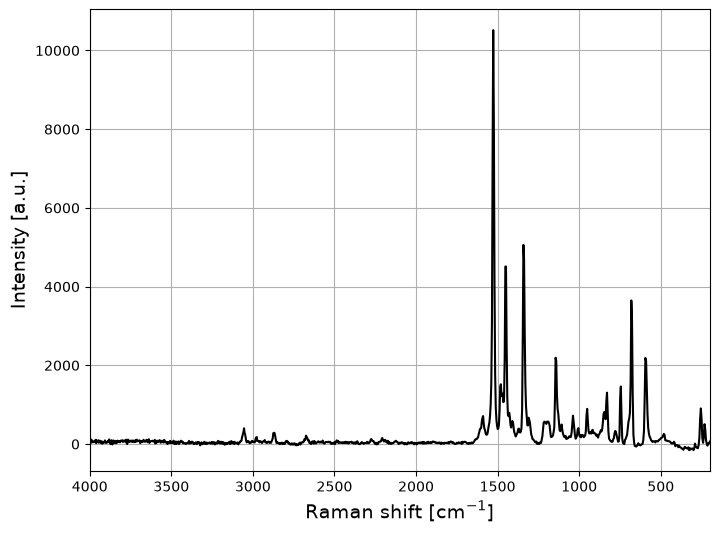

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
x = df["Wavenumber"]
y = df["Intensity"]
ax.plot(x, y, color="black")
ax.set_xlabel("Raman shift [cm$^{-1}$]", fontsize=14)
ax.set_ylabel("Intensity [a.u.]", fontsize=14)
ax.set_xlim(200, 4000)
ax.invert_xaxis()
ax.grid(True)
plt.show()

## 2. RamanSPyを使った可視化とスペクトル処理

ここからは RamanSPy ライブラリを使います。冒頭のセットアップセルで `pip install ramanspy` を済ませてある前提です。

### ライブラリのインポート
RamanSPy は慣例として `rp` というエイリアス名でインポートします。

In [4]:
import ramanspy as rp

### RamanSPyのスペクトルオブジェクトへの変換
RamanSPy はCSVファイルを直接は扱えないため、処理可能な `Spectrum` オブジェクトへ変換する関数を用意します。`rp.Spectrum` の第1引数は強度（1次元配列）、第2引数は波数軸です。

In [5]:
def read_csv(csv_filename):
    """OS-127 形式のCSV（Wavenumber, Intensity）を RamanSPy の Spectrum に変換する。"""
    data = pd.read_csv(csv_filename)
    wavenumber_axis = data["Wavenumber"].values
    intensity = data["Intensity"].values
    return rp.Spectrum(intensity, wavenumber_axis)

In [6]:
spectrum = read_csv(SPECTRUM_PATH)
spectrum

### 2-1. スペクトルの可視化：`ramanspy.plot`

RamanSPy の `ramanspy.plot` モジュールは、公式ドキュメント [Data visualisation](https://ramanspy.readthedocs.io/en/latest/plot.html) にあるとおり、次の可視化関数を提供します。本ノートブック（点スペクトルが対象）で使えるものを順に確認します。

| 関数 | 用途 | 本教材での扱い |
| --- | --- | --- |
| `plot.spectra()` | スペクトル（単一・複数）の描画 | ○ 本節 |
| `plot.peaks()` | ピーク検出つき描画 | ○ 本節 |
| `plot.mean_spectra()` | 複数スペクトルの平均±分布 | ○ 2-2節 |
| `plot.peak_dist()` | 特定バンドのピーク強度分布（棒グラフ） | ○ 2-2節 |
| `plot.image()` | イメージング（2Dマッピング）データの描画 | △ 点スペクトルには非該当（後述） |
| `plot.volume()` | ボリューム（3D）データの描画 | △ 点スペクトルには非該当（後述） |

#### メソッド：`ramanspy.plot.spectra()`
スペクトルオブジェクトを渡すだけでプロットを生成します。内部で Matplotlib が動くため、軸ラベルや色などは Matplotlib の機能で調整できます。

> **⚠️ 実行時の注意（color引数を必ず指定する）**：`rp.plot.spectra()`・`rp.plot.peaks()`・`rp.plot.mean_spectra()` は、`color` を省略すると内部で `matplotlib.cm.get_cmap()` を呼びますが、このAPIは新しい Matplotlib（3.9以降）で廃止されており `AttributeError: module 'matplotlib.cm' has no attribute 'get_cmap'` が発生します。これを避けるため、**本ノートブックではこれらの呼び出しに必ず `color=` を指定**しています（例：`rp.plot.spectra(spectrum, color="black")`）。

**図2**：RamanSPy で描画した CuPc スペクトル

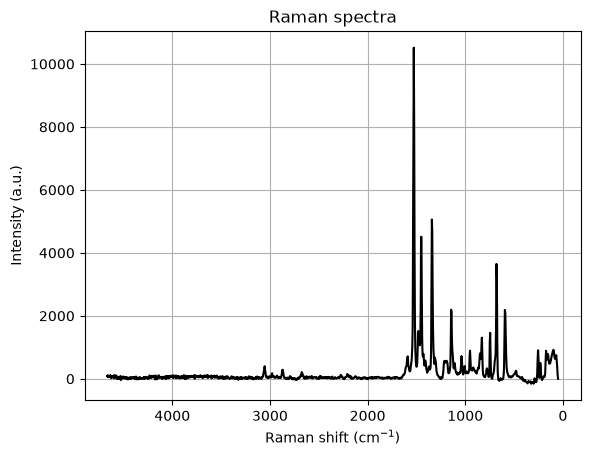

In [7]:
rp.plot.spectra(spectrum, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

#### 主な引数と併用例
`plot.spectra()` でよく使う引数：`plot_type`（`"single"`/`"separate"`/`"stacked"`/`"single stacked"`）、`xlabel`/`ylabel`、`color`、`label`。そのほかの Matplotlib の `plot` 引数もキーワードで渡せます。

**図3**：軸ラベル・色・表示範囲を指定した描画

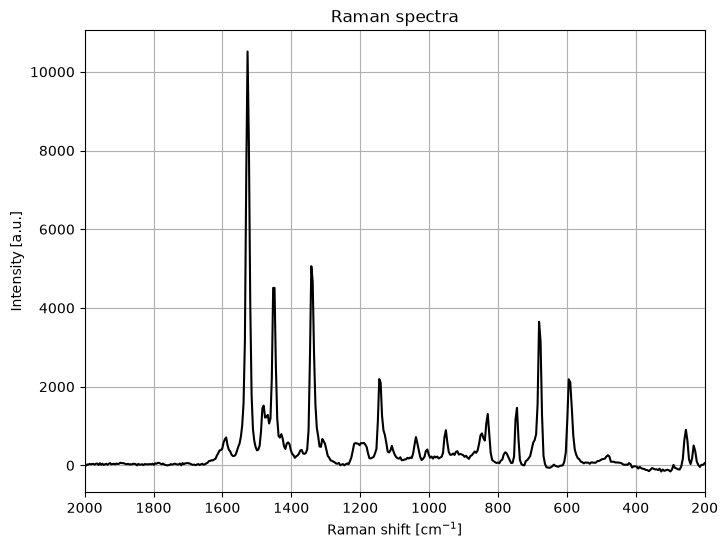

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
rp.plot.spectra(spectrum,
                xlabel="Raman shift [cm$^{-1}$]",
                ylabel="Intensity [a.u.]",
                color="black")
plt.xlim(200, 2000)
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

#### メソッド：`ramanspy.plot.peaks()`
スペクトルを描画しながらピークを検出・表示します。ピーク検出には SciPy の `scipy.signal.find_peaks()` が使われ、`height`・`distance`・`prominence`・`width` などで検出を絞り込めます。`return_peaks=True` でピーク位置・特性を取得することもできます。

**図4**：自動検出されたピーク（全ピーク）

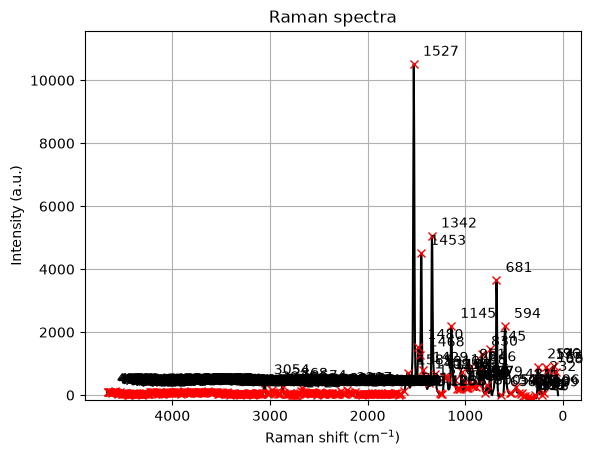

In [9]:
rp.plot.peaks(spectrum, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

**図5**：強度1000以上のピークのみ検出（CuPcの主要バンド ~1340・1450・1530 cm⁻¹ 付近の環伸縮振動などが抽出される）

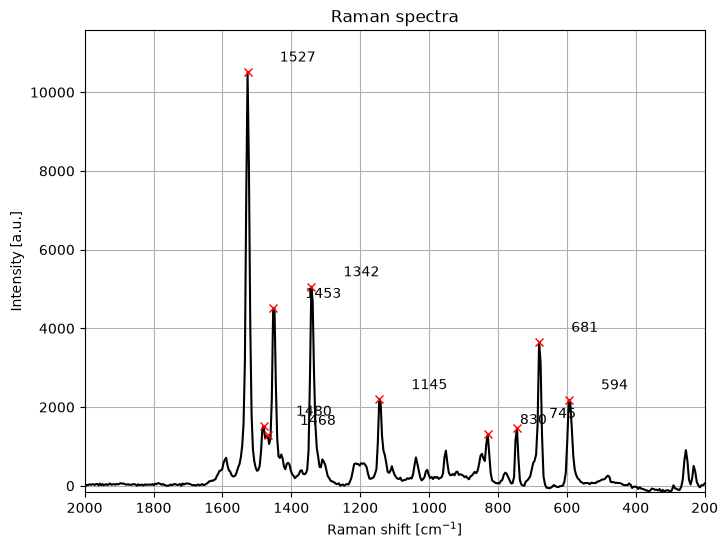

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
rp.plot.peaks(spectrum,
              xlabel="Raman shift [cm$^{-1}$]",
              ylabel="Intensity [a.u.]",
              color="black",
              height=1000)
plt.xlim(200, 2000)
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

### 2-2. 複数スペクトルの可視化：`mean_spectra()` と `peak_dist()`

`plot.mean_spectra()`（平均スペクトル±分布）と `plot.peak_dist()`（特定バンドのピーク強度分布）は、**複数スペクトルの集団**に対する可視化です。ここでは例として、フタロシアニン類3種（CuPc・F16CuPc・無金属フタロシアニン H2Pc）を読み込んで1つのグループとして扱います。

In [11]:
# フタロシアニン類3種を読み込む（同じ波数軸で測定されているグループ）
pc_files = ["CuPc_3_F_npg2_1.csv", "F16CuPc_3_F_npg2_1.csv", "H2Pc_Phthalocyanine_3_F_npg2_1.csv"]
pc_spectra = [read_csv(BASE_DIR / "data" / "spectra" / f) for f in pc_files]

#### メソッド：`ramanspy.plot.mean_spectra()`
スペクトル集団の**平均スペクトルと95%信頼区間**（`dist=True`、既定）、または平均と個々のスペクトル（`dist=False`）を描画します。同種材料のばらつきの把握に使います。

**図6**：フタロシアニン類3種の平均スペクトルと分布

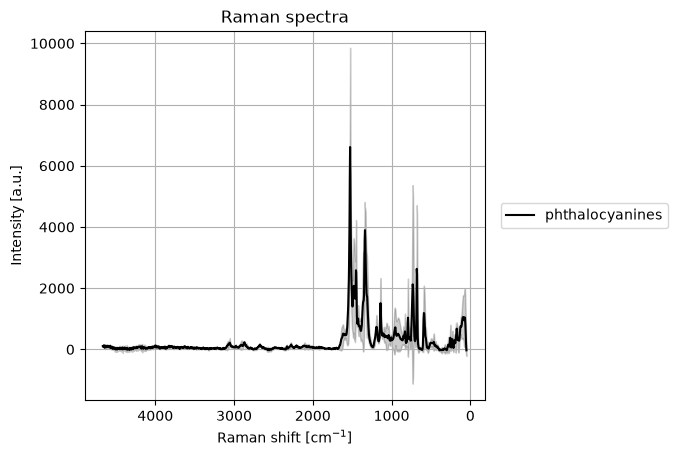

In [12]:
rp.plot.mean_spectra(pc_spectra, dist=True,
                     color="black",
                     label="phthalocyanines",
                     xlabel="Raman shift [cm$^{-1}$]",
                     ylabel="Intensity [a.u.]")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

#### メソッド：`ramanspy.plot.peak_dist()`
指定した波数バンドにおける**ピーク強度の分布**を、集団ごとに棒グラフ（誤差棒=標準偏差）で表示します。特定振動モードの強度を材料間で比較する用途に使います。

**図7**：1530 cm⁻¹ 付近のピーク強度分布

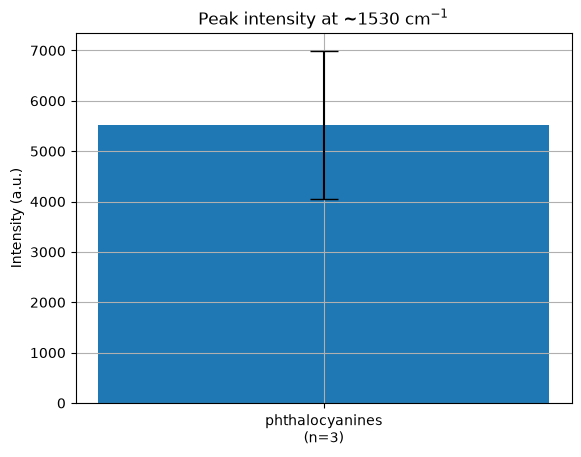

In [30]:
rp.plot.peak_dist(pc_spectra, band=1530,
                  labels=["phthalocyanines"],
                  title="Peak intensity at ~1530 cm$^{-1}$")
plt.grid(True)
plt.show()

#### `plot.image()` と `plot.volume()` について（本データセットでは非該当）
`plot.image()`（2Dマッピング）・`plot.volume()`（3Dボリューム）は、ラマン**イメージング／ボリュームデータ**（各画素・各ボクセルにスペクトルを持つ空間データ）用の可視化関数です。OS-127 は各材料を1点測定（Point measurement）した点スペクトルの集合であり、空間マッピングデータを含まないため、本教材では使用しません。使い方は次の形です（実行にはイメージングデータ `rp.SpectralImage` / `rp.SpectralVolume` が必要）。

```python
# イメージングデータがある場合の例（本データセットには該当データなし）
ax = rp.plot.image(raman_image.band(1500))      # 1500 cm⁻¹ の強度マップ
ax = rp.plot.volume(raman_volume.band(1500))    # 1500 cm⁻¹ のボリューム表示
```

詳細は公式ドキュメント [Visualising imaging data](https://ramanspy.readthedocs.io/en/latest/auto_tutorials/iv-viz/plot_iii_image.html) を参照してください。

## 3. スペクトルの前処理（`ramanspy.preprocessing`）

ここからは前処理を1ステップずつ適用します。公式ドキュメント [Preprocessing](https://ramanspy.readthedocs.io/en/latest/preprocessing.html) に掲載された各カテゴリのメソッドを網羅的に取り上げます。

### 3-1. クロッピング（Cropping）：`misc.Cropper`

**機能**：指定した波数範囲（バンド範囲）だけを切り出します。化学情報が集中する指紋領域に絞ると、後続処理や比較が扱いやすくなります。ここでは 200–1800 cm⁻¹ を切り出します。

**図8**：200–1800 cm⁻¹ にクロッピングしたスペクトル

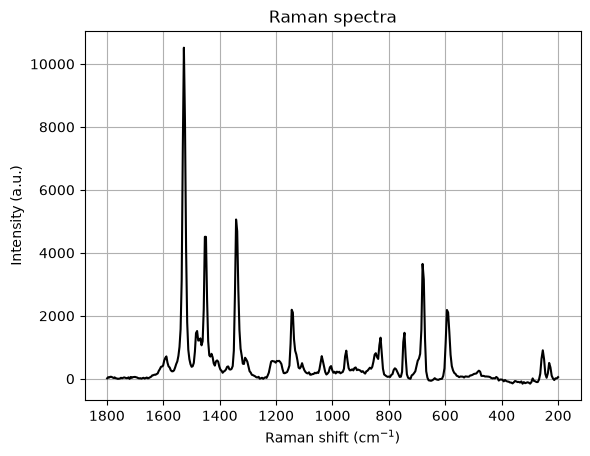

In [14]:
cropper = rp.preprocessing.misc.Cropper(region=(200, 1800))
cropped_spectrum = cropper.apply(spectrum)

rp.plot.spectra(cropped_spectrum, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

### 3-2. 背景の差し引き（Background subtraction）：`misc.BackgroundSubtractor`

**機能**：あらかじめ測定した**参照背景スペクトル**（基板・溶媒・セルなど、目的物質以外に由来する信号）を差し引きます。ベースライン補正（後述）が数理的に背景を推定するのに対し、こちらは**実測した背景そのもの**を引く点が異なります。

本データセットには専用の背景測定が無いため、ここでは API の使い方を示す目的で、緩やかな背景曲線を模擬的に作って差し引きます（実務では別途測定したブランクを使ってください）。

**図9**：模擬背景の差し引き（`BackgroundSubtractor` の使用例）

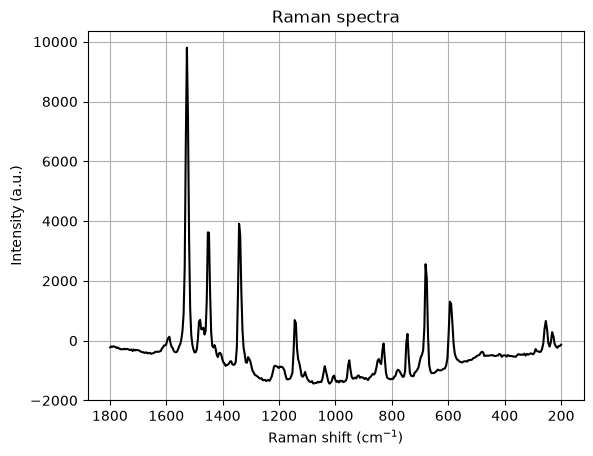

In [15]:
# 模擬的な背景（実務では別途測定したブランクスペクトルを使う）
bg_axis = cropped_spectrum.spectral_axis
bg_curve = 0.15 * np.max(cropped_spectrum.spectral_data) * \
           np.exp(-((bg_axis - bg_axis.mean())**2) / (2 * 400.0**2))
background = rp.Spectrum(bg_curve, bg_axis)

subtractor = rp.preprocessing.misc.BackgroundSubtractor(background=background)
bg_subtracted = subtractor.apply(cropped_spectrum)

rp.plot.spectra(bg_subtracted, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

### 3-3. 宇宙線の除去（Cosmic Ray Removal）：`despike.WhitakerHayes`

**機能**：修正Zスコア（modified z-score）に基づき、宇宙線由来の鋭いスパイク（1〜2点だけ不自然に飛び出た値）を除去します。`kernel_size` はスパイク判定に用いる窓の大きさです。以降はクロッピング済みスペクトルに適用します。

**図10**：宇宙線除去後のスペクトル

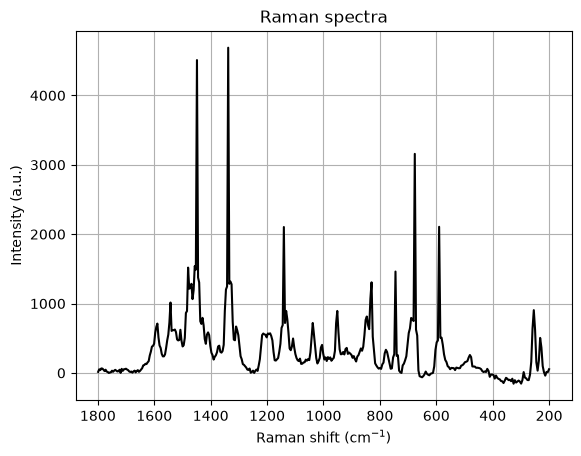

In [16]:
despike = rp.preprocessing.despike.WhitakerHayes(kernel_size=5)
despiked_spectrum = despike.apply(cropped_spectrum)

rp.plot.spectra(despiked_spectrum, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

### 3-4. ノイズ除去（Denoising / Smoothing）

ランダムノイズを抑えて信号対雑音比（S/N）を高めます。RamanSPy は4手法（`SavGol` / `Whittaker` / `Kernel` / `Gaussian`）を備えています。

> **★平滑化の強さに関する重要な注意**：平滑化は強くかけるほどノイズは減りますが、**鋭いラマンピークがなまって（丸まって）しまい、ピーク高さ・位置・幅の情報が失われます**。CuPcのように鋭いピークを持つスペクトルでは、窓幅を大きくしすぎないことが肝心です。本教材では、パラメータを控えめ（ピーク保持を優先）に設定し、さらに過平滑化の弊害を実際に比較して確認します。

#### Savitzky-Golay フィルタ：`denoise.SavGol(window_length, polyorder)`
指定した窓幅 `window_length`（奇数）内で多項式（次数 `polyorder`）を当てはめて平滑化します。窓を広げるほど強く平滑化されますが、ピークがなまります。

CuPcスペクトルの波数刻みは約 3.4 cm⁻¹ です。旧版では `window_length=15`（≈51 cm⁻¹幅）としていましたが、これはラマンピークの半値幅（およそ 10–20 cm⁻¹）より広く、**鋭いピークを丸めすぎ**でした。ここではピークを保持できる **`window_length=7`（≈24 cm⁻¹幅）, `polyorder=3`** を用います。

**図11**：Savitzky-Golay 平滑化後（window_length=7, polyorder=3）

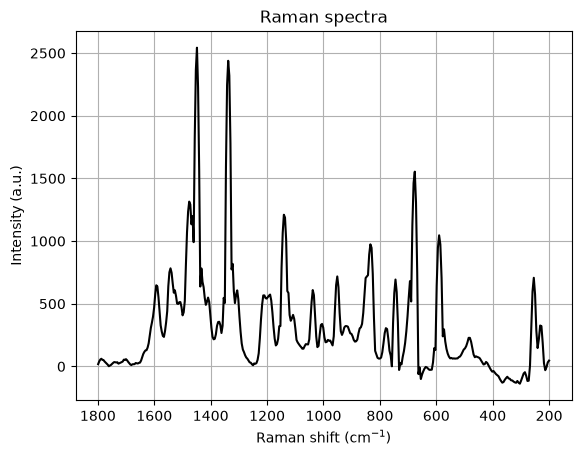

In [17]:
# ピーク保持を優先した控えめな平滑化（旧版の window_length=15 は過平滑だった）
SG_WINDOW_LENGTH = 7
SG_POLYORDER = 3

sg_filter = rp.preprocessing.denoise.SavGol(window_length=SG_WINDOW_LENGTH, polyorder=SG_POLYORDER)
sg_filtered = sg_filter.apply(despiked_spectrum)

rp.plot.spectra(sg_filtered, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

#### 過平滑化（over-smoothing）の確認
窓幅を変えて平滑化の効き方を比較します。窓幅を大きくするほどピークがなまる様子を、CuPcの主要ピーク（~1340・1450・1530 cm⁻¹）で確認してください。

**図12**：窓幅による平滑化の違い（5=弱 / 7=適切 / 15=やや過剰 / 31=過平滑）

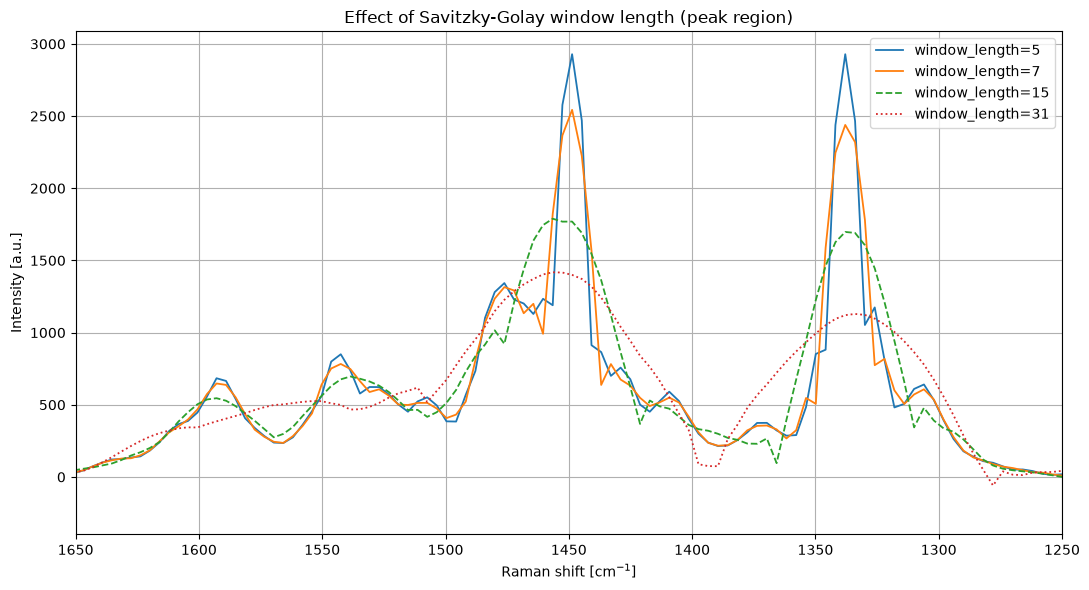

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
axis = despiked_spectrum.spectral_axis
for wl, style in [(5, "-"), (7, "-"), (15, "--"), (31, ":")]:
    filt = rp.preprocessing.denoise.SavGol(window_length=wl, polyorder=3).apply(despiked_spectrum)
    ax.plot(axis, filt.spectral_data, style, lw=1.3, label=f"window_length={wl}")
ax.set_xlim(1250, 1650)   # 主要ピーク付近を拡大
ax.invert_xaxis()
ax.set_xlabel("Raman shift [cm$^{-1}$]")
ax.set_ylabel("Intensity [a.u.]")
ax.set_title("Effect of Savitzky-Golay window length (peak region)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_savgol_window_comparison.png", dpi=150)
plt.show()

#### Whittaker（離散ペナルティ付き最小二乗）：`denoise.Whittaker(lam, d)`
全体の滑らかさを罰則項 `lam` で制御します。`lam` を大きくするほど滑らかになり、小さくするほど元の詳細を残します。ここでは**ピークを保持できる控えめな `lam=50`** を用います（旧版の `lam=1000` は過平滑気味）。`d` は差分行列の階数（通常2）です。

**図13**：Whittaker 平滑化後（lam=50, d=2）

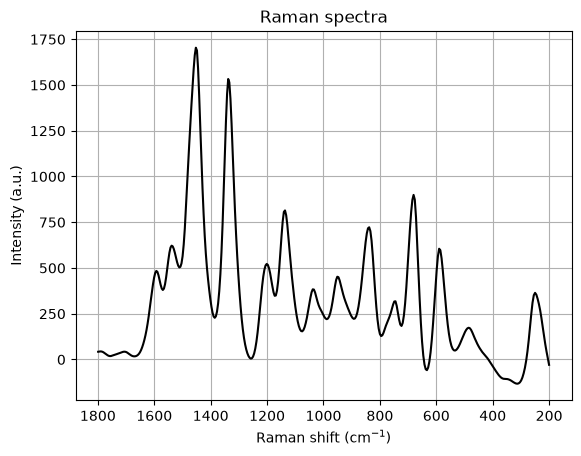

In [19]:
whittaker = rp.preprocessing.denoise.Whittaker(lam=50, d=2)
whittaker_filtered = whittaker.apply(despiked_spectrum)

rp.plot.spectra(whittaker_filtered, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

#### カーネル／ウィンドウ平滑化：`denoise.Kernel(kernel_type, kernel_size)`
各点を近傍点の加重平均で置き換えます。`kernel_type="flat"` は単純移動平均に相当します。窓を小さめ（`kernel_size=5`）にしてピークを保ちます。

**図14**：カーネル平滑化後（flat, kernel_size=5）

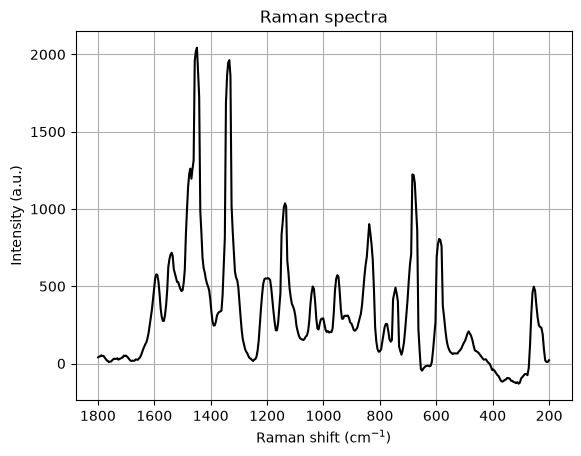

In [20]:
kernel = rp.preprocessing.denoise.Kernel(kernel_type="flat", kernel_size=5)
kernel_filtered = kernel.apply(despiked_spectrum)

rp.plot.spectra(kernel_filtered, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

#### ガウシアンフィルタ：`denoise.Gaussian(sigma, ...)`
ガウス関数を重みに用いた平滑化です。`sigma` が大きいほど強く平滑化されます。ピーク保持のため小さめの `sigma=1.5` を指定します。

**図15**：ガウシアン平滑化後（sigma=1.5）

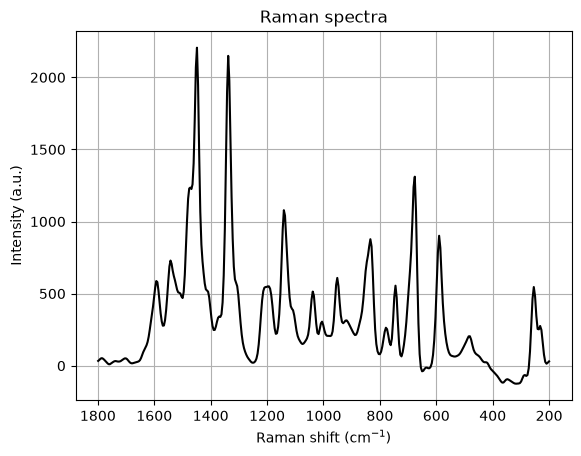

In [21]:
gaussian = rp.preprocessing.denoise.Gaussian(sigma=1.5)
gaussian_filtered = gaussian.apply(despiked_spectrum)

rp.plot.spectra(gaussian_filtered, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

### 3-5. ベースライン補正（Baseline Correction）

蛍光や装置由来の緩やかな背景を推定して差し引きます。RamanSPy は多数の手法を、**最小二乗系・多項式フィッティング系・その他**の3グループで提供します。以降は Savitzky-Golay 平滑化後（`sg_filtered`）に適用します。

#### 代表例：適応的平滑化ペナルティ付き最小二乗法（asPLS）：`baseline.ASPLS`
まず1手法を詳しく見ます。asPLSは、ピーク部分とベースライン部分を反復的に重み付けしながら滑らかな背景を推定して差し引きます。主な引数は `lam`（平滑化パラメータ。大きいほど背景が滑らか）で、多くの場合は既定値で良好に動作します。

**図16**：asPLS によるベースライン補正後

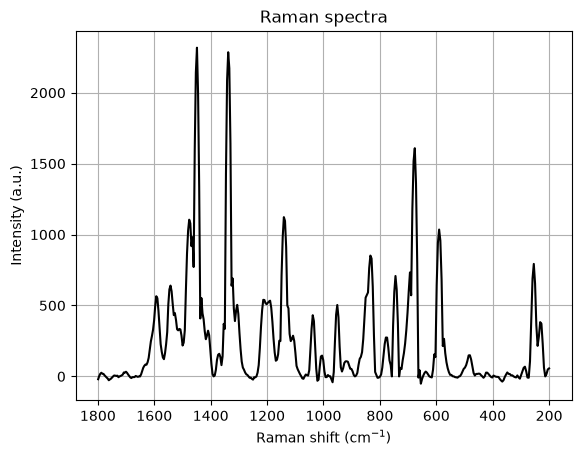

In [22]:
baseline = rp.preprocessing.baseline.ASPLS()
baseline_corrected = baseline.apply(sg_filtered)

rp.plot.spectra(baseline_corrected, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

#### ベースライン補正手法の網羅比較
RamanSPy が備える主なベースライン補正手法を一覧で適用し、結果を並べて比較します。手法によって推定される背景が異なるため、試料に応じた選択が重要です。

- **最小二乗系**：`ASLS`, `IASLS`, `AIRPLS`, `ARPLS`, `DRPLS`, `IARPLS`, `ASPLS`
- **多項式フィッティング系**：`Poly`, `ModPoly`, `PenalisedPoly`, `IModPoly`
- **その他**：`Goldindec`, `IRSQR`, `CornerCutting`, `FABC`

（各手法はバージョンにより引数や可用性が異なる場合があるため、`try/except` で失敗した手法はスキップし、実行できた手法だけを表示します。）

**図17**：ベースライン補正手法の比較

[skip] FABC: TypeError: numpy.apply_along_axis() got multiple values for keyword argument 'x_data'


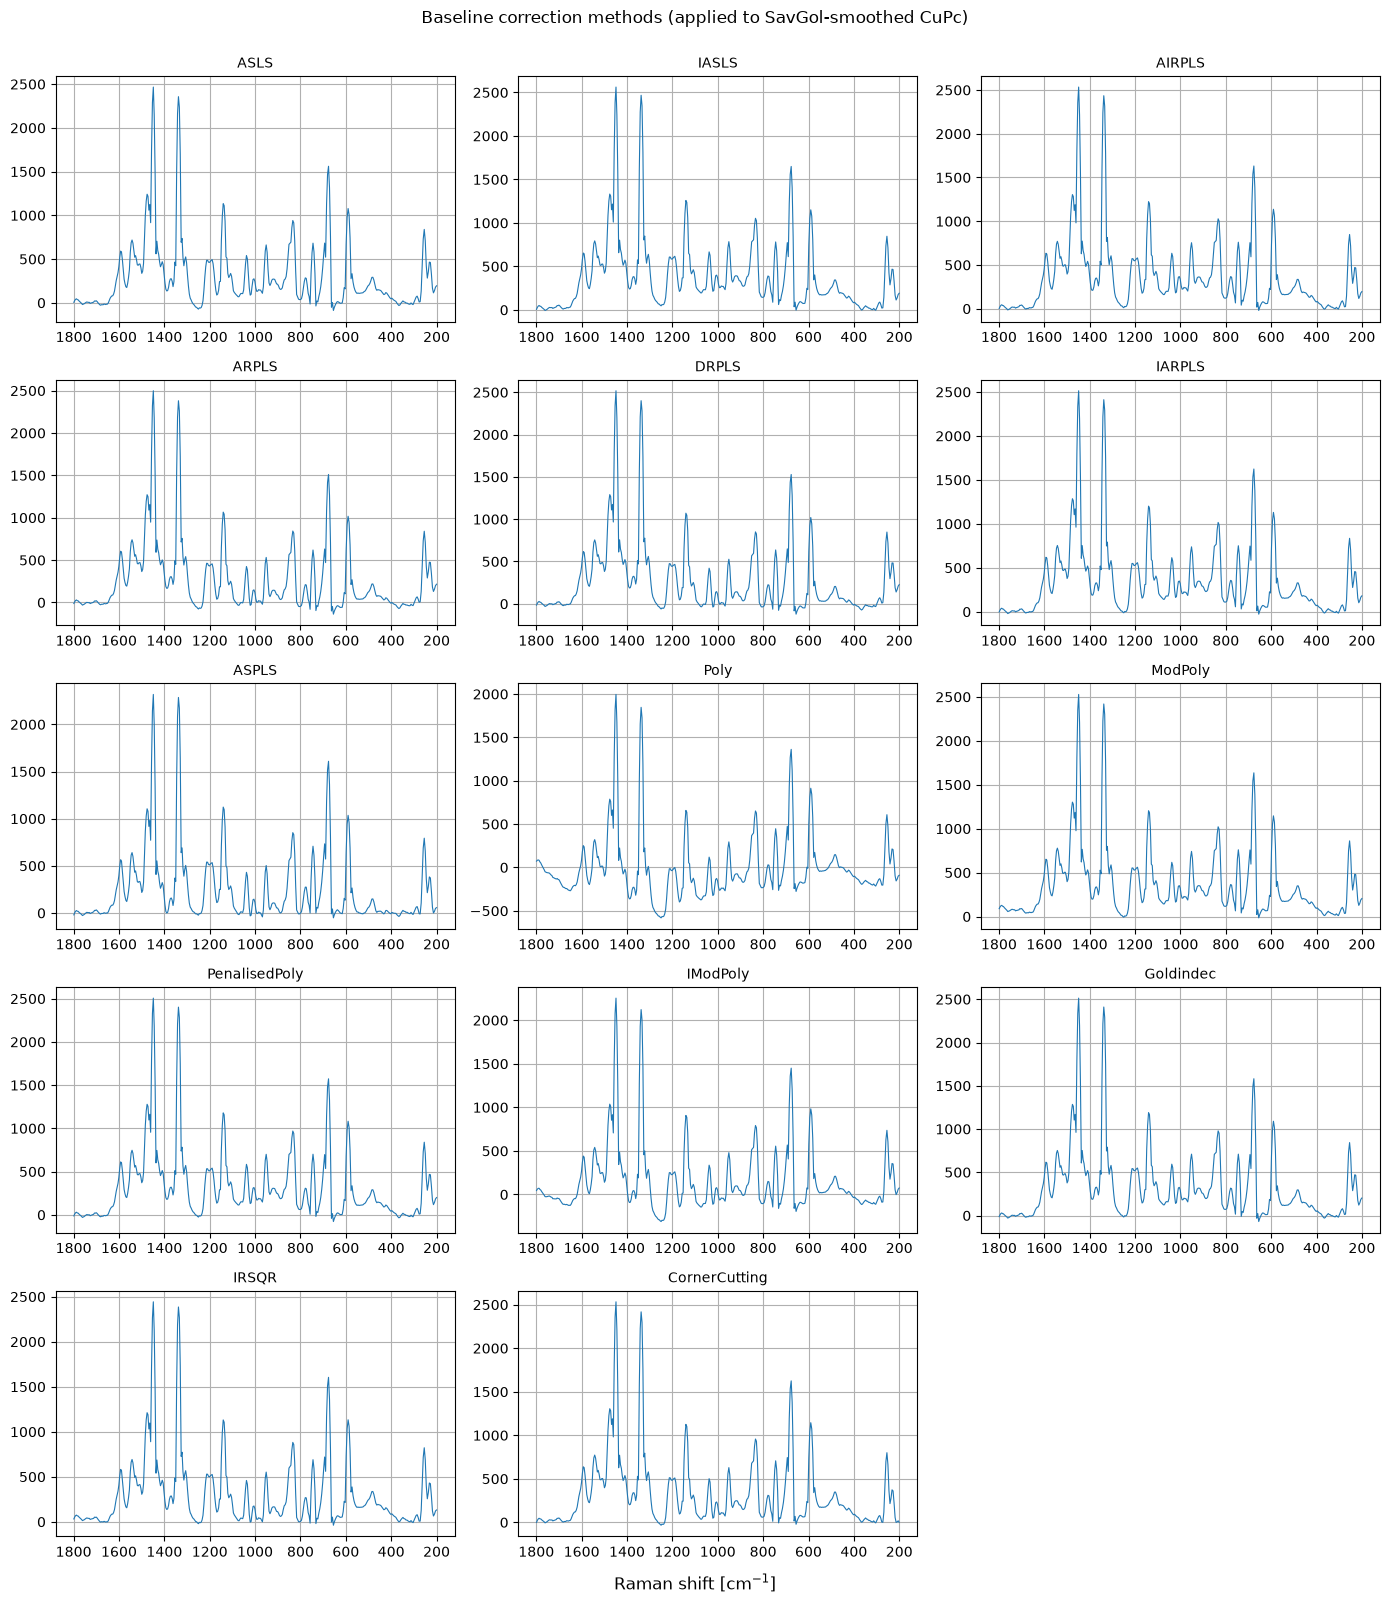

In [23]:
baseline_methods = {
    # 最小二乗系
    "ASLS":   rp.preprocessing.baseline.ASLS(),
    "IASLS":  rp.preprocessing.baseline.IASLS(),
    "AIRPLS": rp.preprocessing.baseline.AIRPLS(),
    "ARPLS":  rp.preprocessing.baseline.ARPLS(),
    "DRPLS":  rp.preprocessing.baseline.DRPLS(),
    "IARPLS": rp.preprocessing.baseline.IARPLS(),
    "ASPLS":  rp.preprocessing.baseline.ASPLS(),
    # 多項式フィッティング系
    "Poly":          rp.preprocessing.baseline.Poly(poly_order=3),
    "ModPoly":       rp.preprocessing.baseline.ModPoly(poly_order=3),
    "PenalisedPoly": rp.preprocessing.baseline.PenalisedPoly(poly_order=3),
    "IModPoly":      rp.preprocessing.baseline.IModPoly(poly_order=3),
    # その他
    "Goldindec":     rp.preprocessing.baseline.Goldindec(poly_order=3),
    "IRSQR":         rp.preprocessing.baseline.IRSQR(),
    "CornerCutting": rp.preprocessing.baseline.CornerCutting(),
    "FABC":          rp.preprocessing.baseline.FABC(),
}

results = {}
for name, method in baseline_methods.items():
    try:
        results[name] = method.apply(sg_filtered)
    except Exception as e:
        print(f"[skip] {name}: {type(e).__name__}: {e}")

n = len(results)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
for ax, (name, corr) in zip(axes.ravel(), results.items()):
    ax.plot(corr.spectral_axis, corr.spectral_data, lw=0.8, color="C0")
    ax.set_title(name, fontsize=10)
    ax.invert_xaxis()
    ax.grid(True)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("Baseline correction methods (applied to SavGol-smoothed CuPc)", y=1.0)
fig.supxlabel("Raman shift [cm$^{-1}$]")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_baseline_comparison.png", dpi=150)
plt.show()

### 3-6. 規格化（Normalisation）

測定ごとのレーザー強度や露光時間の違いを吸収し、スペクトル同士を比較可能にします。RamanSPy は4手法を備えています。ベースライン補正後（`baseline_corrected`）に適用し、4手法を比較します。

- `Vector`：スペクトルベクトルの長さ（L2ノルム）を1にそろえる。
- `MinMax`：最小値・最大値が指定範囲 `[a, b]`（既定 `[0, 1]`）に収まるようスケーリング。
- `MaxIntensity`：最大強度を基準（=1）にする。
- `AUC`：曲線下面積（Area Under the Curve）を1にそろえる。

> **実行時の注意（`AUC` が失敗する／表示されない場合）**：**NumPy 2.0 以降では `np.trapz` が `np.trapezoid` に改称・削除**されており、RamanSPy の `normalise.AUC` は内部で `np.trapz` を呼ぶため `AttributeError: module 'numpy' has no attribute 'trapz'` で失敗します（その結果、ループが途中で止まり AUC パネルが描画されない）。下のセルでは各手法を `try/except` で個別に評価し、`AUC` が失敗した場合は**バージョン非依存の台形積分（`np.trapezoid` があればそれ、無ければ `np.trapz`）で面積を求める手動計算にフォールバック**して必ず出力します。各手法の出力レンジ（min/max）も `print` して確認します。

**図18**：4つの規格化手法の比較

normalise.Vector      : min=-0.00557, max=0.251
normalise.MinMax      : min=0, max=1
normalise.MaxIntensity: min=-0.0222, max=1
normalise.AUC         : min=-0.000127, max=0.00574


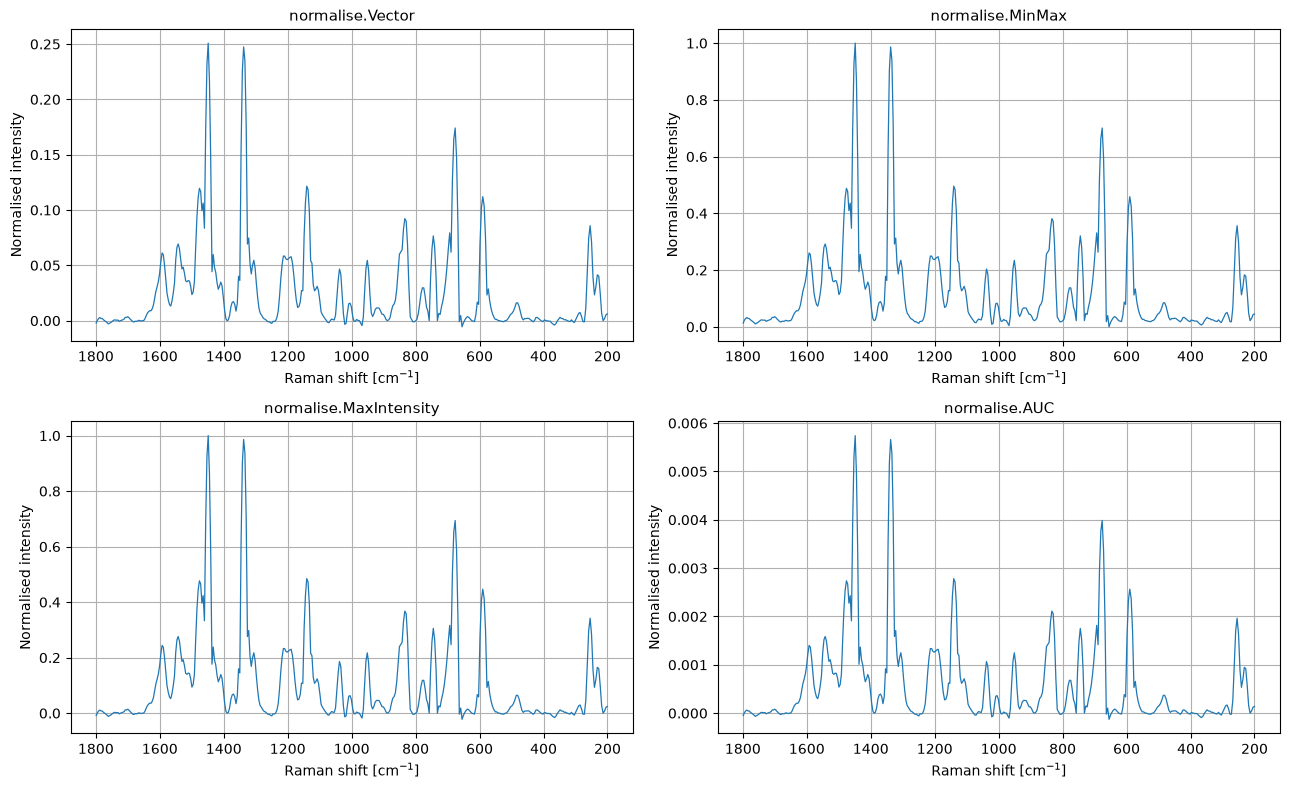

In [24]:
normalisers = {
    "Vector":       rp.preprocessing.normalise.Vector(),
    "MinMax":       rp.preprocessing.normalise.MinMax(),
    "MaxIntensity": rp.preprocessing.normalise.MaxIntensity(),
    "AUC":          rp.preprocessing.normalise.AUC(),
}

# 参照用（フォールバック計算に使う）
axis0 = np.asarray(baseline_corrected.spectral_axis, float)
y0 = np.asarray(baseline_corrected.spectral_data, float)

# NumPy 2.0 で np.trapz は np.trapezoid に改称された。
# RamanSPy の AUC は内部で np.trapz を呼ぶため NumPy 2.0 環境では失敗する。
# 手動フォールバックはバージョン非依存の台形積分を使う。
_trapezoid = getattr(np, "trapezoid", getattr(np, "trapz", None))

def normalise_fallback(name, axis, values):
    """RamanSPy の正規化が失敗した場合の手動フォールバック。"""
    if name == "Vector":
        return values / np.linalg.norm(values)
    if name == "MinMax":
        return (values - values.min()) / (values.max() - values.min())
    if name == "MaxIntensity":
        return values / np.max(np.abs(values))
    if name == "AUC":                                   # 曲線下面積（台形則）で割る
        return values / _trapezoid(values, axis)
    return values

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (name, norm) in zip(axes.ravel(), normalisers.items()):
    try:
        normalised = norm.apply(baseline_corrected)
        x = np.asarray(normalised.spectral_axis, float)
        y = np.asarray(normalised.spectral_data, float)
        note = ""
    except Exception as e:
        # 特に AUC で環境依存の不具合が出る場合はここで手動計算に切り替える
        print(f"[fallback] normalise.{name}: {type(e).__name__}: {e}")
        x, y = axis0, normalise_fallback(name, axis0, y0)
        note = " (fallback)"
    print(f"normalise.{name:12}: min={np.min(y):.3g}, max={np.max(y):.3g}")
    ax.plot(x, y, lw=0.9, color="C0")
    ax.set_title(f"normalise.{name}{note}", fontsize=11)
    ax.set_xlabel("Raman shift [cm$^{-1}$]")
    ax.set_ylabel("Normalised intensity")
    ax.invert_xaxis()
    ax.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_normalisation_comparison.png", dpi=150)
plt.show()

### 3-7. 確立された前処理プロトコル（`preprocessing.protocols`）

RamanSPy は、論文で提案された**あらかじめ構成済みの前処理パイプライン**（プロトコル）も提供します。手法やパラメータの選択に悩まず、確立された手順をそのまま適用できます。

各プロトコルは呼び出すと `Pipeline` を返す関数です（公式ソースで確認）。中身は次のとおりです。

| プロトコル | 構成ステップ（指紋領域 700–1800 cm⁻¹ にクロップ後） |
| --- | --- |
| `georgiev2023_P1` | 宇宙線除去 → Gaussian → **ASLS** → **AUC 規格化** |
| `georgiev2023_P2` | 宇宙線除去 → SavGol(9,3) → **asPLS** → MinMax 規格化 |
| `georgiev2023_P3` | 宇宙線除去 → **Poly(3)** ベースライン → Vector 規格化 |
| `bergholt2016` | Poly(2) ベースライン → クロップ → Vector 規格化 → 宇宙線除去 |

> **注意（`georgiev2023_P1` が表示されない場合）**：P1 の最終ステップ `normalise.AUC` は内部で `np.trapz` を使うため、**NumPy 2.0 環境では冒頭の互換シムが無いと `AttributeError` で失敗**します（P2・P3・bergholt2016 は AUC を使わないため影響を受けません）。本ノートブックは冒頭のセットアップで `np.trapz` を復元しているので P1 も動作します。

生スペクトルに各プロトコルを適用して比較します（環境差に備え `try/except` で保護し、失敗時はパネルに理由を表示）。

**図19**：確立プロトコルによる前処理結果の比較

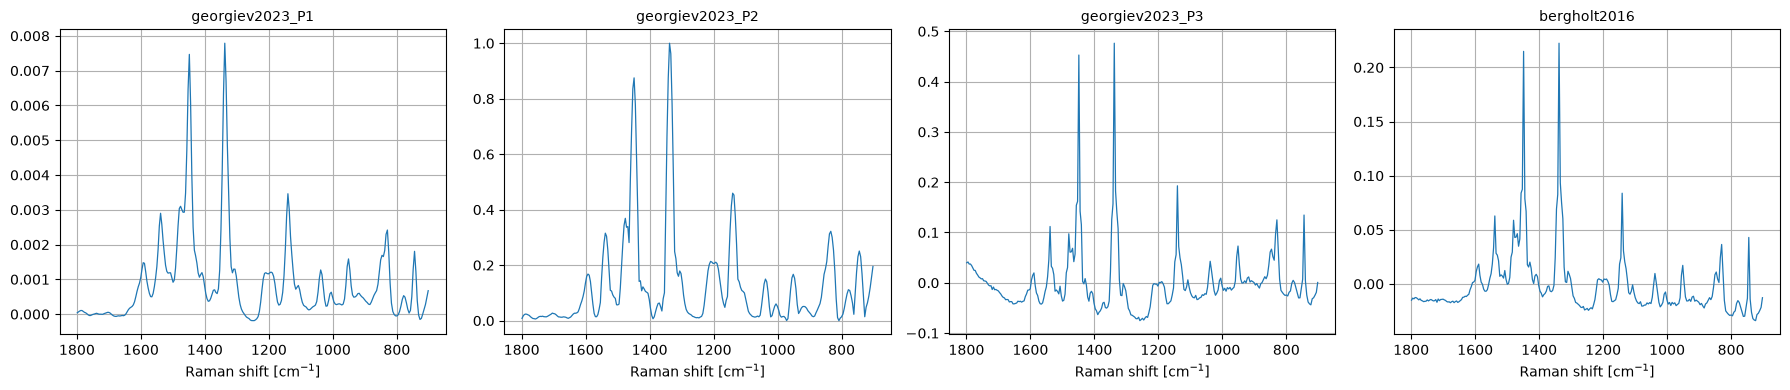

In [25]:
protocols = {
    "georgiev2023_P1": rp.preprocessing.protocols.georgiev2023_P1,
    "georgiev2023_P2": rp.preprocessing.protocols.georgiev2023_P2,
    "georgiev2023_P3": rp.preprocessing.protocols.georgiev2023_P3,
    "bergholt2016":    rp.preprocessing.protocols.bergholt2016,
}

raw_for_protocol = read_csv(SPECTRUM_PATH)
fig, axes = plt.subplots(1, len(protocols), figsize=(4.5 * len(protocols), 4))
for ax, (name, proto_factory) in zip(np.atleast_1d(axes), protocols.items()):
    try:
        pipeline = proto_factory()             # プロトコルは Pipeline を返す
        processed = pipeline.apply(raw_for_protocol)
        ax.plot(processed.spectral_axis, processed.spectral_data, lw=0.9, color="C0")
        ax.set_title(name, fontsize=10)
    except Exception as e:
        print(f"[skip] {name}: {type(e).__name__}: {e}")
        ax.set_title(f"{name}\n[skip: {type(e).__name__}]", fontsize=9)
    ax.set_xlabel("Raman shift [cm$^{-1}$]")
    ax.invert_xaxis()
    ax.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_protocols.png", dpi=150)
plt.show()

### 3-8. 手法選択の体系的な指針（平滑化・ベースライン補正）

平滑化もベースライン補正も多数の手法があり、「どれをいつ使うか」を体系的に判断する基準が必要です。ここでは選択の考え方を整理し、続くコードで**手法間の違いを定量指標で比較**します。

#### (1) 平滑化（ノイズ除去）の選択基準

| 判断軸 | 見るべき点 | 推奨 |
| --- | --- | --- |
| ピークの鋭さ | 鋭い（FWHMが狭い）ほど形状保存が重要 | **SavGol**（形状保存が最良） |
| 大域的な滑らかさ制御 | 窓長を決めず1つのツマミで調整したい | **Whittaker**（`lam` を対数で調整） |
| リップルの無さ | 素直で予測可能な広がりがほしい | **Gaussian** |
| 速度・単純さ最優先 | 定量解析をしない粗い均し | **Kernel(flat)**（ただしピークはなまりやすい） |

**基本方針**：分光では **SavGol を第一選択**とし、窓幅を最も鋭いピークの半値幅（点数換算）以下に設定する。詳細は付属資料 `RamanSPy-1_denoising_guide.md` を参照。

#### (2) ベースライン補正の選択基準

ベースライン補正法は、背景（ベースライン）の**形状**と、スペクトルの**ピーク密度**、**チューニングの手間**で選びます。

| 判断軸 | 状況 | 推奨手法 |
| --- | --- | --- |
| 背景の形 | なだらかな蛍光バックグラウンド | 罰則付き最小二乗系（**asPLS / arPLS / airPLS**）。反復重み付けでピークを避けて背景を推定 |
| 背景の形 | 低次多項式で近似できる単純な背景 | **Poly / ModPoly / IModPoly**（`poly_order` 2〜3） |
| ピーク密度 | ピークが密集（重なりが多い） | **arPLS / asPLS**（非対称重み付けでピークを引きすぎない）。多項式系は苦手 |
| チューニングの手間 | パラメータ調整を避けたい | **FABC / arPLS**（自動性が高い） |
| 過剰減算の回避 | 補正後に負値が多い＝引きすぎ | `p`（非対称度）を小さく、`lam` を調整。多項式系は次数を下げる |
| 速度 | 大量スペクトルを高速処理 | 多項式系は高速。反復PLS系は中程度 |

**基本方針**：ラマンの蛍光背景には **asPLS / arPLS を既定**とし、背景が単純なら低次 **ModPoly** も検討。**補正後に負の領域が大きい／ピークが削れているものは「引きすぎ」**のサインです。

#### (3) 違いを定量的に見る指標

視覚比較（3-4節の平滑化比較図・3-5節のベースライン網羅比較図）に加え、次の客観指標で手法を比べます。

- **平滑化**：`roughness`（2階差分の標準偏差。小さいほど滑らか）と `peak_retention`（主ピーク高さの保持率。1に近いほどピークを保つ）。**両者はトレードオフ**で、良い手法は「滑らかさは十分・ピーク保持は高い」。
- **ベースライン**：`neg_frac`（負値の割合＝過剰減算の指標）、`baseline_offset`／`baseline_roughness`（ピークの無い低強度領域の平均・ばらつき＝背景除去の残り）、`peak_retention`（主ピークの保持率）。

#### 平滑化4手法の定量比較
生スペクトル（despike済み）に4手法を適用し、`roughness`（滑らかさ）と `peak_retention`（ピーク保持率）を比較します。

**図20**：平滑化手法の定量比較

参考: 生スペクトル（despike済み）の roughness = 735.5502
        method  roughness  peak_retention
   SavGol(7,3) 170.735163        0.520198
 Whittaker(50)  16.448199        0.327001
Kernel(flat,5) 122.934128        0.415439
 Gaussian(1.5)  60.241333        0.458399


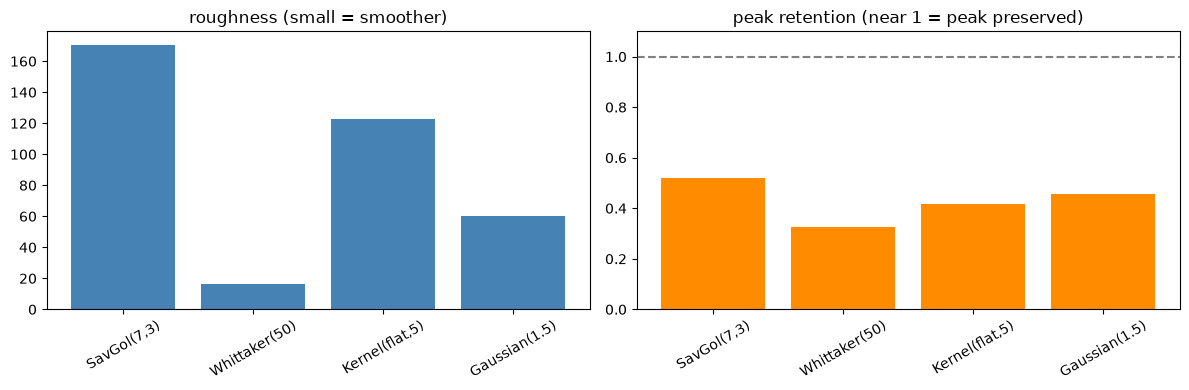

In [26]:
def roughness(values):
    """2階差分の標準偏差。小さいほど滑らか（ノイズが少ない）。"""
    return float(np.std(np.diff(np.asarray(values, float), n=2)))

raw_despiked = np.asarray(despiked_spectrum.spectral_data, float)
peak_idx = int(np.argmax(raw_despiked))          # 主ピークの位置

smoothers = {
    "SavGol(7,3)":    rp.preprocessing.denoise.SavGol(window_length=7, polyorder=3),
    "Whittaker(50)":  rp.preprocessing.denoise.Whittaker(lam=50, d=2),
    "Kernel(flat,5)": rp.preprocessing.denoise.Kernel(kernel_type="flat", kernel_size=5),
    "Gaussian(1.5)":  rp.preprocessing.denoise.Gaussian(sigma=1.5),
}

rows = []
for name, sm in smoothers.items():
    try:
        z = np.asarray(sm.apply(despiked_spectrum).spectral_data, float)
        rows.append({"method": name,
                     "roughness": roughness(z),
                     "peak_retention": z[peak_idx] / raw_despiked[peak_idx]})
    except Exception as e:
        print(f"[skip] {name}: {type(e).__name__}: {e}")

smooth_metrics = pd.DataFrame(rows)
print(f"参考: 生スペクトル（despike済み）の roughness = {roughness(raw_despiked):.4f}")
print(smooth_metrics.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(smooth_metrics["method"], smooth_metrics["roughness"], color="steelblue")
axes[0].set_title("roughness (small = smoother)"); axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(smooth_metrics["method"], smooth_metrics["peak_retention"], color="darkorange")
axes[1].axhline(1.0, color="gray", ls="--"); axes[1].set_ylim(0, 1.1)
axes[1].set_title("peak retention (near 1 = peak preserved)"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_smoothing_metrics.png", dpi=150)
plt.show()

#### ベースライン補正手法の定量比較
平滑化後スペクトル（`sg_filtered`）に代表的な5手法（ASLS・ARPLS・ASPLS・AIRPLS・ModPoly）を適用し、`neg_frac`（過剰減算）・`baseline_offset`／`baseline_roughness`（背景除去の残り）・`peak_retention`（ピーク保持）を比較します。

> **補足（`FABC` を含めていない理由）**：`FABC`（Fully Automatic Baseline Correction）は内部で追加のライブラリ（`pybaselines`／ウェーブレット系）に依存し、NumPy・SciPy のバージョンによっては実行時エラーで落ちることがあります。この定量比較では確実に動作する軽量な最小二乗系5手法に絞りました（`FABC` を含む全15手法の描画比較は「3-5. ベースライン補正手法の網羅比較」で `try/except` 付きで扱っています。そこで `FABC` が描画されない場合は、環境依存でスキップされた（＝手法が不適切なのではなく、実行時エラーで除外された）ことを意味し、出力の `[skip] FABC: ...` にその理由が表示されます）。

**図21**：ベースライン補正手法の定量比較

    method  neg_frac  baseline_offset  baseline_roughness  peak_retention
      ASLS  0.023196         5.657298           33.970828        0.969824
     ARPLS  0.051546        25.052395           28.325258        0.982545
     ASPLS  0.002577         3.648477           11.713356        0.911250
    AIRPLS  0.000000        43.273226           39.030972        0.996226
ModPoly(3)  0.000000        67.430440           36.581079        0.993839


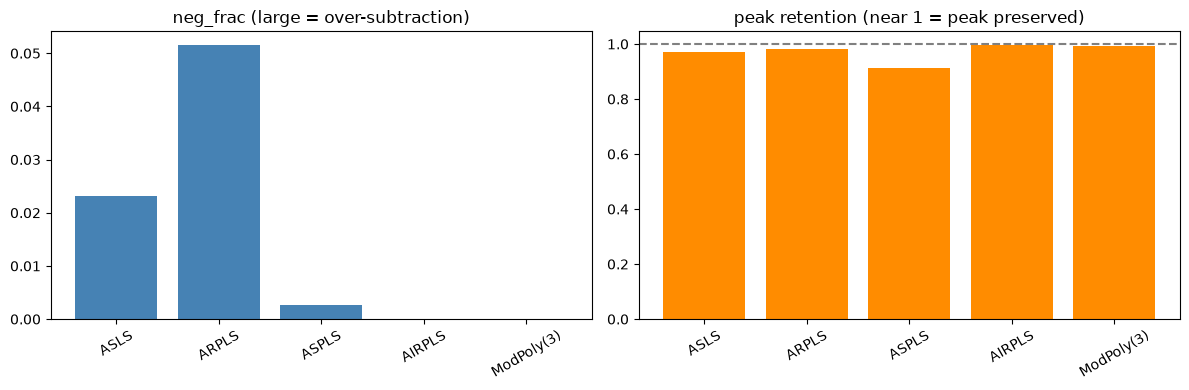

In [27]:
def neg_fraction(values, rel_tol=0.02):
    """負値（引きすぎ）の割合。最大絶対値に対する相対しきい値で判定。"""
    v = np.asarray(values, float)
    tol = rel_tol * np.max(np.abs(v))
    return float(np.mean(v < -tol))

def baseline_flatness(values, low_pct=30):
    """低強度側（ピークが無い領域の代理）の平均の絶対値とばらつきを返す。"""
    v = np.asarray(values, float)
    base = v[v <= np.percentile(v, low_pct)]
    return float(abs(np.mean(base))), float(np.std(base))

sg_vals = np.asarray(sg_filtered.spectral_data, float)
pk = int(np.argmax(sg_vals))

baseline_candidates = {
    "ASLS":       rp.preprocessing.baseline.ASLS(),
    "ARPLS":      rp.preprocessing.baseline.ARPLS(),
    "ASPLS":      rp.preprocessing.baseline.ASPLS(),
    "AIRPLS":     rp.preprocessing.baseline.AIRPLS(),
    "ModPoly(3)": rp.preprocessing.baseline.ModPoly(poly_order=3),
}

rows = []
for name, method in baseline_candidates.items():
    try:
        z = np.asarray(method.apply(sg_filtered).spectral_data, float)
        offset, rough = baseline_flatness(z)
        rows.append({"method": name,
                     "neg_frac": neg_fraction(z),
                     "baseline_offset": offset,
                     "baseline_roughness": rough,
                     "peak_retention": z[pk] / sg_vals[pk]})
    except Exception as e:
        print(f"[skip] {name}: {type(e).__name__}: {e}")

baseline_metrics = pd.DataFrame(rows)
print(baseline_metrics.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(baseline_metrics["method"], baseline_metrics["neg_frac"], color="steelblue")
axes[0].set_title("neg_frac (large = over-subtraction)"); axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(baseline_metrics["method"], baseline_metrics["peak_retention"], color="darkorange")
axes[1].axhline(1.0, color="gray", ls="--")
axes[1].set_title("peak retention (near 1 = peak preserved)"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_baseline_metrics.png", dpi=150)
plt.show()

#### 指標の読み方（まとめ）
- **平滑化**：`Kernel(flat)` は `roughness` を下げやすい反面 `peak_retention` が最も低くなりがち。`SavGol` は滑らかさと保持のバランスが良い。数値と3-4節の窓幅比較図（過平滑化の確認）を併せて、ピークをなまさない範囲で最も滑らかな手法・パラメータを選ぶ。
- **ベースライン**：`neg_frac` が大きい手法は**引きすぎ**（ピーク裾や谷を負に削っている）。`baseline_offset`/`baseline_roughness` が小さいほど背景がフラットに除けている。`peak_retention` が極端に小さい手法はピークまで削っている疑い。**これらのバランスで手法を選ぶ**（単一指標で決めない）。
- 実データでは唯一の正解はなく、**複数手法を定量指標＋目視で比較して選ぶ**のが実務の基本です。

## 4. パイプライン化（`preprocessing.Pipeline`）

実際の解析では、上記の前処理を毎回同じ順序で複数スペクトルに適用します。`Pipeline` クラスを使うと、一連の前処理を1つのオブジェクトにまとめ、`apply()` を呼ぶだけで順に実行できます。手順の再現性が保証され、多数のスペクトルへの一括適用も容易になります（一括適用は続編 `RamanSPy-2` で扱います）。

`Pipeline` は `append()`（末尾追加）・`insert(index, step)`（挿入）・`extend(steps)`（複数追加）・`pop(index)`（削除）で後から構成を編集することもできます。

ここでは「クロッピング → 宇宙線除去 → Savitzky-Golay 平滑化（window_length=7）→ ベースライン補正（asPLS）→ Min-max 規格化」を1本にまとめます。

**図22**：パイプライン一括適用後の最終スペクトル

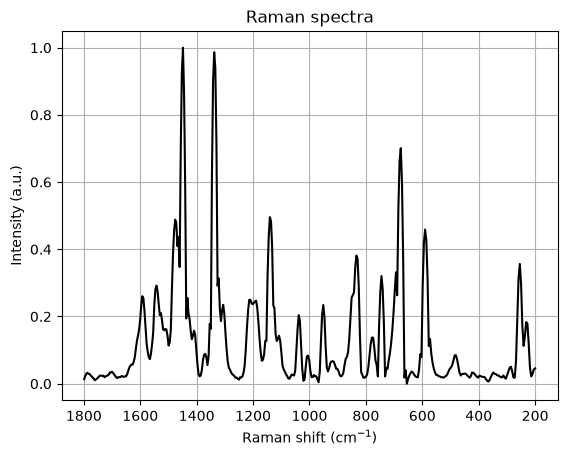

In [28]:
# 前処理を1本にまとめる（上から順に適用される）
pipeline = rp.preprocessing.Pipeline([
    rp.preprocessing.misc.Cropper(region=(200, 1800)),
    rp.preprocessing.despike.WhitakerHayes(kernel_size=5),
    rp.preprocessing.denoise.SavGol(window_length=SG_WINDOW_LENGTH, polyorder=SG_POLYORDER),
    rp.preprocessing.baseline.ASPLS(),
    rp.preprocessing.normalise.MinMax(),
])

# 生スペクトルに一括適用
raw_spectrum = read_csv(SPECTRUM_PATH)
preprocessed_spectrum = pipeline.apply(raw_spectrum)

rp.plot.spectra(preprocessed_spectrum, color="black")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

### 前処理済みスペクトルの保存
前処理済みスペクトルを `output/` フォルダにCSVで保存します（波数軸と強度の2列）。

In [29]:
output_path = OUTPUT_DIR / "CuPc_preprocessed.csv"
result = pd.DataFrame({
    "Wavenumber": preprocessed_spectrum.spectral_axis,
    "Intensity": preprocessed_spectrum.spectral_data,
})
result.to_csv(output_path, index=False)
print(f"saved: {output_path}  (shape={result.shape})")

saved: output\CuPc_preprocessed.csv  (shape=(388, 2))


## 5. まとめ（作業全体のふりかえり）

本ノートブックでは、OS-127 データセットの CuPc スペクトルを例に、RamanSPy の可視化・前処理メソッドを**公式ドキュメント掲載分を網羅**して確認しました。

**可視化（`ramanspy.plot`）**：`spectra()`（描画）、`peaks()`（ピーク検出）、`mean_spectra()`（平均±分布）、`peak_dist()`（バンド強度分布）。`image()`・`volume()` は空間マッピング／ボリューム用のため、点スペクトルの本データセットでは非該当であることを説明しました。

**前処理（`ramanspy.preprocessing`）**：
- クロッピング（`Cropper`）、背景差し引き（`BackgroundSubtractor`）
- 宇宙線除去（`WhitakerHayes`）
- ノイズ除去4手法（`SavGol` / `Whittaker` / `Kernel` / `Gaussian`）。**平滑化は強くかけすぎるとピークがなまる**ため、窓幅を控えめ（SavGol window_length=7）に設定し、過平滑化の弊害も比較しました。
- ベースライン補正（最小二乗系7種・多項式系4種・その他4種を網羅比較）
- 規格化4手法（`Vector` / `MinMax` / `MaxIntensity` / `AUC`）
- 確立プロトコル（`georgiev2023_P1/P3` / `bergholt2016`）
- パイプライン化（`Pipeline`）

**ワークフローの要点**：①クロッピング→②宇宙線除去→③ノイズ除去→④ベースライン補正→⑤規格化、の順に適用することで、スペクトル同士を対等に比較できる状態に整えました。この整形済みスペクトルが、次章以降のケモメトリクス（多変量解析・機械学習）の入力になります。

## 6. 本ノートブックで扱っていないこと（今後の課題）

- **前処理手法の定量的な最適化**：`window_length`・`lam`・`poly_order`・クロッピング範囲などは代表値を用いました。S/Nやピーク保持を指標にした最適化は扱っていません。
- **複数スペクトルの一括処理と比較**：本章は1本のスペクトルが中心です。45本すべてを一括処理してデータ行列を作り、クラスタリングや分類へ進む流れは続編で扱います。
- **手法選択の体系的な指針**：多数のベースライン補正法・平滑化法のどれをいつ使うべきかの基準。
- **イメージング／ボリュームデータ**：`plot.image()`・`plot.volume()` は該当データが無いため使用していません。
- **定量分析（濃度推定など）**：本章は前処理・可視化に限定しています。

## 7. 演習問題

1. **平滑化の強さ**：Savitzky-Golay の `window_length` を 5・7・15・31 と変えたとき（図の過平滑化比較を参照）、CuPcの主要ピーク（~1450・1530 cm⁻¹）の高さと幅はどう変化しますか。「適切な平滑化」と「過平滑化」の境目を自分の言葉で説明してください。
2. **ベースライン手法の選択**：`Rubrene_S785` のように蛍光背景が強いスペクトルに、網羅比較のベースライン手法群を適用し、どの手法が最も自然な補正を与えるか比較してください。
3. **規格化の使い分け**：`Vector`・`MinMax`・`MaxIntensity`・`AUC` では、強い単一ピークがある場合にスペクトル全体の見え方がどう変わるか、図で比較して説明してください。
4. **プロトコルの活用**：確立プロトコル（`georgiev2023_P1` など）と、自分で組んだ `Pipeline` の結果を比較し、違いを考察してください。
5. **別の材料で試す**：`SPECTRUM_PATH` を `PEDOT_PSS_F532_npg2_1.csv` に変えて全セルを再実行し、ノイズやベースラインの性質の違いに応じて適切な前処理パラメータを選び直してください。